# Clustering Exploration

This notebook explores how different slab, weak-layer, and Extended Column Test (ECT) feature choices change two-cluster K-means results in the SnowPylot dataset. The workflow is intentionally linear: load CAAML pits, build slabs from the layer of concern, derive slab/weak-layer/ECT features, then compare a fixed two-cluster workflow across multiple feature sets.

PCA is used for interpretation and visualization. K-means is fit on the full standardized feature matrix for each feature set so the clustering step uses all retained input information, not just the first two principal components.

Cluster labels are exploratory. The near-avalanche marker is held out as contextual metadata, not as an input feature or a supervised target. Terrain, season, location, operation, elevation, slope, and aspect are intentionally excluded from PCA and clustering inputs.

## Setup

All imports, paths, model settings, feature-set definitions, and display labels live here so the rest of the notebook reads like an analysis narrative. Feature sets are organized by purpose: minimal slab load, weak-layer-only, primary physical slab/weak-layer features, log-transform sensitivity, ECT sensitivity, and low-coverage D11 sensitivity.

In [1]:
import re
import sys
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
    NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SNOWPYT_MECHPARAMS_SRC = PROJECT_ROOT.parent / "SnowPyt-MechParams" / "src"
for import_path in [NOTEBOOK_DIR, SNOWPYT_MECHPARAMS_SRC]:
    import_path_text = str(import_path)
    if import_path.exists() and import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from caaml_utils import parse_caaml_directory
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.models import Pit

try:
    from tqdm.auto import tqdm
except ImportError:

    def tqdm(items, **_kwargs):
        return items

warnings.filterwarnings(
    "ignore",
    message="Using UFloat objects with std_dev==0 may give unexpected results.",
)

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = PROJECT_ROOT / "snowpits" / "2015_2025"
RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 2
ECT_MAX_TAPS = 31.0
CLUSTER_ORDER_COLUMN = "slab_weight_N_m2"
PERMUTATION_N_ITERATIONS = 1000

ANALYSIS_METADATA_COLUMNS = [
    "pit_id",
    "slab_id",
    "near_avalanche_flag",
    "near_avalanche_raw",
    "near_avalanche_status",
]

FEATURE_SET_DEFINITIONS = {
    "slab_load": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
    ],
    "weak_layer_core": [
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "slab_plus_weak_layer": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "log_transform_sensitivity": [
        "log1p_slab_thickness_cm",
        "log1p_slab_weight_N_m2",
        "n_layers",
        "log1p_cumulative_hhi_cm",
        "log1p_slab_mean_hhi",
        "log1p_weak_layer_depth_top_cm",
        "log1p_weak_layer_thickness_cm",
        "log1p_weak_layer_hhi",
        "weak_layer_persistent_grain",
    ],
    "ect_response_sensitivity": [
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_mean_propagating_taps",
        "ect_instability_index",
    ],
    "slab_weak_layer_plus_ect": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "ect_propagation_rate",
        "ect_mean_taps",
        "ect_mean_propagating_taps",
        "ect_instability_index",
    ],
    "d11_sensitivity": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "bending_stiffness_D11_N_mm",
    ],
    "slab_weak_layer_d11_sensitivity": [
        "slab_thickness_cm",
        "slab_weight_N_m2",
        "n_layers",
        "cumulative_hhi_cm",
        "slab_mean_hhi",
        "weak_layer_depth_top_cm",
        "weak_layer_thickness_cm",
        "weak_layer_hhi",
        "weak_layer_persistent_grain",
        "bending_stiffness_D11_N_mm",
    ],
}

FORBIDDEN_PCA_FEATURE_COLUMNS = set(ANALYSIS_METADATA_COLUMNS) | {
    "near_avalanche",
    "near_avalanche_label",
    "pit_date",
    "season",
    "month",
    "operation_name",
    "country",
    "region",
    "elevation",
    "slope_angle",
    "aspect",
}
LOG_TRANSFORM_SOURCE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "weak_layer_depth_top_cm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
]

COVERAGE_FEATURE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "n_layers",
    "cumulative_hhi_cm",
    "slab_mean_hhi",
    "weak_layer_depth_top_cm",
    "weak_layer_thickness_cm",
    "weak_layer_hhi",
    "weak_layer_persistent_grain",
    "bending_stiffness_D11_N_mm",
    "ect_propagation_rate",
    "ect_mean_taps",
    "ect_mean_propagating_taps",
    "ect_instability_index",
    "ect_count",
    "ect_parsed_count",
]
FEATURE_DISPLAY_NAMES = {
    "slab_thickness_cm": "Slab thickness (cm)",
    "slab_weight_N_m2": "Slab weight (N/m2)",
    "n_layers": "Slab layer count",
    "cumulative_hhi_cm": "Cumulative HHI (cm)",
    "slab_mean_hhi": "Thickness-weighted mean slab HHI",
    "weak_layer_depth_top_cm": "Weak-layer top depth (cm)",
    "weak_layer_thickness_cm": "Weak-layer thickness (cm)",
    "weak_layer_hhi": "Weak-layer HHI",
    "weak_layer_persistent_grain": "Weak-layer persistent grain flag",
    "bending_stiffness_D11_N_mm": "Bending stiffness D11 (N mm)",
    "ect_propagation_rate": "ECT propagation rate",
    "ect_mean_taps": "ECT mean taps",
    "ect_mean_propagating_taps": "ECT mean propagating taps",
    "ect_instability_index": "ECT instability index",
    "ect_count": "ECT count",
    "ect_parsed_count": "Parsed ECT count",
}
for source_column in LOG_TRANSFORM_SOURCE_COLUMNS:
    FEATURE_DISPLAY_NAMES[f"log1p_{source_column}"] = (
        f"log1p {FEATURE_DISPLAY_NAMES[source_column]}"
    )

WEIGHT_METHODS = {
    "density": "kim_jamieson_table2",
    "slab_weight": "sum_layer_weight",
}
D11_METHODS = {
    "density": "kim_jamieson_table2",
    "elastic_modulus": "schottner",
    "poissons_ratio": "kochle",
    "D11": "weissgraeber_rosendahl",
}

pd.options.display.float_format = "{:,.3f}".format

## Helper Functions

These helpers keep the analysis cells short. They handle uncertain values, missing values, avalanche-context labels, slab-level hand-hardness summaries, ECT score parsing, and permutation diagnostics.

In [2]:
def nominal_value(value):
    """Return a finite float from a scalar, unit tuple/list, or uncertainties value."""
    if value is None:
        return np.nan
    if isinstance(value, (list, tuple)):
        if not value:
            return np.nan
        value = value[0]
    value = getattr(value, "nominal_value", value)
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def near_avalanche_status_from_raw(value):
    """Keep true, false, and missing avalanche context distinct."""
    if value is True:
        return "Near avalanche"
    if value is False:
        return "Explicitly not near avalanche"
    return "Unknown/not recorded"


def cumulative_hhi_cm(slab):
    """Sum layer hand hardness index multiplied by layer thickness in cm."""
    total = 0.0
    for layer in slab.layers:
        hhi = nominal_value(layer.hand_hardness_index)
        thickness = nominal_value(layer.thickness)
        if np.isnan(hhi) or np.isnan(thickness):
            return np.nan
        total += hhi * thickness
    return total


def slab_mean_hhi(slab):
    """Return thickness-weighted mean slab hand hardness index."""
    cumulative_hhi = cumulative_hhi_cm(slab)
    slab_thickness = nominal_value(slab.total_thickness)
    if np.isnan(cumulative_hhi) or np.isnan(slab_thickness) or slab_thickness <= 0:
        return np.nan
    return cumulative_hhi / slab_thickness


def weak_layer_persistent_grain_flag(weak_layer):
    """Flag depth hoar, facets, or surface hoar weak layers."""
    if weak_layer is None:
        return np.nan
    grain_form = getattr(weak_layer, "main_grain_form", None)
    if grain_form is None:
        raw_grain_form = getattr(weak_layer, "grain_form", None)
        grain_form = str(raw_grain_form)[:2] if raw_grain_form is not None else None
    if grain_form is None:
        return np.nan
    return float(str(grain_form).upper() in {"DH", "FC", "SH"})


def log1p_positive(series):
    """Return log1p for non-negative finite values and NaN otherwise."""
    numeric_series = pd.to_numeric(series, errors="coerce")
    return np.where(numeric_series >= 0, np.log1p(numeric_series), np.nan)


def mean_or_nan(values):
    """Return the mean of finite values, or NaN when no finite values exist."""
    valid_values = [value for value in values if not np.isnan(value)]
    return float(np.mean(valid_values)) if valid_values else np.nan


def parse_ect_result(ect):
    """Parse one ECT result into propagation, tap count, depth, and instability score."""
    score = (getattr(ect, "test_score", None) or "").strip().upper()
    propagation = np.nan
    taps = np.nan
    depth_top = nominal_value(getattr(ect, "depth_top", None))

    # ECTPV is propagation during isolation. ECTX is treated as non-propagating
    # at the maximum score so tap-based summaries stay on the ECT 0-31 scale.
    if score == "ECTPV":
        propagation = 1.0
        taps = 0.0
    elif score == "ECTX":
        propagation = 0.0
        taps = ECT_MAX_TAPS
    elif score.startswith("ECT") and len(score) >= 4:
        propagation_code = score[3]
        if propagation_code == "P":
            propagation = 1.0
        elif propagation_code in {"N", "X"}:
            propagation = 0.0

        tap_match = re.search(r"\d+", score[4:] if len(score) > 4 else "")
        if tap_match:
            taps = float(tap_match.group(0))
    elif getattr(ect, "propagation", None) is not None:
        propagation = 1.0 if ect.propagation else 0.0

    if np.isnan(taps) and getattr(ect, "num_taps", None) is not None:
        tap_match = re.search(r"\d+", str(ect.num_taps))
        if tap_match:
            taps = float(tap_match.group(0))

    if np.isnan(propagation):
        instability = np.nan
    elif propagation == 0.0:
        instability = 0.0
    elif np.isnan(taps):
        instability = np.nan
    else:
        instability = float(np.clip((ECT_MAX_TAPS - taps) / ECT_MAX_TAPS, 0.0, 1.0))

    return {
        "score": score,
        "propagation": propagation,
        "taps": taps,
        "depth_top": depth_top,
        "instability": instability,
    }


def summarize_ect_results(ect_results):
    """Summarize all ECT results attached to a slab."""
    parsed_results = [parse_ect_result(ect) for ect in ect_results]
    propagation_values = [result["propagation"] for result in parsed_results]
    tap_values = [result["taps"] for result in parsed_results]
    depth_values = [result["depth_top"] for result in parsed_results]
    instability_values = [result["instability"] for result in parsed_results]
    propagating_taps = [
        result["taps"]
        for result in parsed_results
        if result["propagation"] == 1.0 and not np.isnan(result["taps"])
    ]
    parsed_count = sum(
        not np.isnan(result["propagation"]) or not np.isnan(result["taps"])
        for result in parsed_results
    )

    return {
        "ect_count": len(ect_results),
        "ect_parsed_count": parsed_count,
        "ect_propagation_rate": mean_or_nan(propagation_values),
        "ect_mean_taps": mean_or_nan(tap_values),
        "ect_mean_propagating_taps": mean_or_nan(propagating_taps),
        "ect_mean_depth_top_cm": mean_or_nan(depth_values),
        "ect_instability_index": mean_or_nan(instability_values),
        "has_ECT": len(ect_results) > 0,
        "has_ECT_features": parsed_count > 0,
    }


def pc_count_for_variance(explained_variance_ratio, threshold):
    """Return the first PC count whose cumulative variance reaches threshold."""
    cumulative_variance = np.cumsum(explained_variance_ratio)
    return int(np.searchsorted(cumulative_variance, threshold, side="left") + 1)


def between_cluster_rate_difference(clustered_df, label_column="near_avalanche_flag"):
    """Return the absolute difference in near-avalanche rates between two clusters."""
    rates = clustered_df.groupby("ordered_cluster")[label_column].mean()
    if len(rates) < 2:
        return np.nan
    return float((rates.max() - rates.min()) * 100)


def permutation_rate_difference_p_value(clustered_df):
    """Estimate whether the cluster rate difference exceeds random label assignment."""
    observed_difference = between_cluster_rate_difference(clustered_df)
    if np.isnan(observed_difference):
        return np.nan

    labels = clustered_df["near_avalanche_flag"].astype(float).to_numpy()
    if labels.sum() == 0 or labels.sum() == len(labels):
        return np.nan

    rng = np.random.default_rng(RANDOM_STATE)
    cluster_ids = clustered_df["ordered_cluster"].to_numpy()
    permuted_differences = []
    for _ in range(PERMUTATION_N_ITERATIONS):
        permuted_df = pd.DataFrame(
            {
                "ordered_cluster": cluster_ids,
                "near_avalanche_flag": rng.permutation(labels),
            }
        )
        permuted_differences.append(between_cluster_rate_difference(permuted_df))

    return float(
        (np.sum(np.array(permuted_differences) >= observed_difference) + 1)
        / (PERMUTATION_N_ITERATIONS + 1)
    )

## Data Loading

Parse the CAAML files, then convert SnowPylot pits into SnowPyt-MechParams pit objects for slab creation and mechanical-property calculations.


In [3]:
raw_pits = parse_caaml_directory(DATA_DIR)
mech_pits = [Pit.from_snow_pit(pit) for pit in raw_pits]

loading_summary_df = pd.DataFrame(
    {
        "metric": ["CAAML directory", "Parsed SnowPylot pits", "Converted mech pits"],
        "value": [str(DATA_DIR), f"{len(raw_pits):,}", f"{len(mech_pits):,}"],
    }
)
loading_summary_df


,metric,value
0,CAAML directory,/Users/marykate/Desktop/Snow/snowpylot-applica...
1,Parsed SnowPylot pits,"50,278"
2,Converted mech pits,"50,278"


## Slab And Weak-Layer Feature Engineering

Each slab is created from the layer of concern. The feature table keeps identifiers, the original near-avalanche marker, an explicit avalanche-context status, slab load/structure features, core weak-layer features, and D11 for low-coverage sensitivity analysis.

In [4]:
slab_records = []

for raw_pit, mech_pit in zip(raw_pits, mech_pits):
    location = raw_pit.core_info.location
    near_avalanche_raw = location.pit_near_avalanche
    near_avalanche_status = near_avalanche_status_from_raw(near_avalanche_raw)
    ect_results = raw_pit.stability_tests.ECT if raw_pit.stability_tests else []

    for slab in mech_pit.create_slabs(weak_layer_def="layer_of_concern"):
        slab_records.append(
            {
                "pit_id": mech_pit.pit_id,
                "near_avalanche_flag": near_avalanche_raw is True,
                "near_avalanche_raw": near_avalanche_raw,
                "near_avalanche_status": near_avalanche_status,
                "slab": slab,
                "slab_layers": slab.layers,
                "snow_pit": raw_pit,
                "mech_pit": mech_pit,
                "ect_results": ect_results,
            }
        )

slab_status_counts_df = pd.Series(
    [record["near_avalanche_status"] for record in slab_records],
    name="near_avalanche_status",
).value_counts(dropna=False).rename_axis("near_avalanche_status").reset_index(name="slab_count")

slab_summary_df = pd.DataFrame(
    {
        "metric": ["Usable slabs", "Slabs marked near avalanche"],
        "value": [
            f"{len(slab_records):,}",
            f"{sum(record['near_avalanche_flag'] for record in slab_records):,}",
        ],
    }
)

display(slab_summary_df)
slab_status_counts_df

,metric,value
0,Usable slabs,"34,690"
1,Slabs marked near avalanche,"1,381"


,near_avalanche_status,slab_count
0,Unknown/not recorded,33309
1,Near avalanche,1381


In [5]:
engine = ExecutionEngine()
feature_records = []

for slab_record in tqdm(slab_records, desc="Creating slab features", unit="slab"):
    slab = slab_record["slab"]
    weak_layer = slab.weak_layer

    weight_result = engine.execute_single(slab, "slab_weight", WEIGHT_METHODS)
    slab_weight = (
        nominal_value(weight_result.slab.slab_weight)
        if weight_result is not None and weight_result.success
        else np.nan
    )

    d11_result = engine.execute_single(slab, "D11", D11_METHODS)
    bending_stiffness = (
        nominal_value(d11_result.slab.D11)
        if d11_result is not None and d11_result.success
        else np.nan
    )

    feature_records.append(
        {
            "pit_id": slab_record["pit_id"],
            "slab_id": slab.slab_id,
            "near_avalanche_flag": slab_record["near_avalanche_flag"],
            "near_avalanche_raw": slab_record["near_avalanche_raw"],
            "near_avalanche_status": slab_record["near_avalanche_status"],
            "n_layers": len(slab.layers),
            "slab_thickness_cm": nominal_value(slab.total_thickness),
            "slab_weight_N_m2": slab_weight,
            "bending_stiffness_D11_N_mm": bending_stiffness,
            "cumulative_hhi_cm": cumulative_hhi_cm(slab),
            "slab_mean_hhi": slab_mean_hhi(slab),
            "weak_layer_depth_top_cm": nominal_value(
                getattr(weak_layer, "depth_top", None)
            ),
            "weak_layer_thickness_cm": nominal_value(
                getattr(weak_layer, "thickness", None)
            ),
            "weak_layer_hhi": nominal_value(
                getattr(weak_layer, "hand_hardness_index", None)
            ),
            "weak_layer_persistent_grain": weak_layer_persistent_grain_flag(weak_layer),
        }
    )

slab_features_df = pd.DataFrame(feature_records)

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df

,feature,display_name,non_null_count,coverage
0,slab_thickness_cm,Slab thickness (cm),34690,1.000
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427
2,n_layers,Slab layer count,34690,1.000
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721
4,slab_mean_hhi,Thickness-weighted mean slab HHI,25027,0.721
5,weak_layer_depth_top_cm,Weak-layer top depth (cm),34690,1.000
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000
7,weak_layer_hhi,Weak-layer HHI,31316,0.903
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913
9,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046


## ECT Features

ECT strings are converted into numerical summaries for sensitivity feature sets. Propagating tests with fewer taps receive a higher instability score; non-propagating tests receive zero. Rows with unparseable ECT data keep missing values and are filtered out only for feature sets that include ECT variables. The parser QA table below makes the score rules explicit before those features are used.

In [6]:
# Quick parser QA for common ECT encodings before applying the parser to the corpus.
ect_parser_examples = [
    SimpleNamespace(test_score="ECTPV", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTX", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTP12", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTN4", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="ECTN25", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score="bad score", num_taps=None, depth_top=[10.0, "cm"]),
    SimpleNamespace(test_score=None, num_taps=None, depth_top=None),
]
ect_parser_qa_df = pd.DataFrame(
    [parse_ect_result(ect_example) for ect_example in ect_parser_examples]
)

ect_feature_records = [
    summarize_ect_results(slab_record["ect_results"])
    for slab_record in slab_records
]
ect_features_df = pd.DataFrame(ect_feature_records)

slab_features_df = pd.concat(
    [slab_features_df.reset_index(drop=True), ect_features_df],
    axis=1,
)

for source_column in LOG_TRANSFORM_SOURCE_COLUMNS:
    slab_features_df[f"log1p_{source_column}"] = log1p_positive(
        slab_features_df[source_column]
    )

feature_coverage_df = pd.DataFrame(
    {
        "feature": [
            column
            for column in COVERAGE_FEATURE_COLUMNS
            if column in slab_features_df.columns
        ],
    }
)
feature_coverage_df["display_name"] = feature_coverage_df["feature"].map(
    FEATURE_DISPLAY_NAMES
)
feature_coverage_df["non_null_count"] = [
    slab_features_df[column].notna().sum()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["coverage"] = [
    slab_features_df[column].notna().mean()
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["used_in_any_feature_set"] = [
    any(column in feature_columns for feature_columns in FEATURE_SET_DEFINITIONS.values())
    for column in feature_coverage_df["feature"]
]
feature_coverage_df["low_coverage_sensitivity_feature"] = (
    feature_coverage_df["used_in_any_feature_set"]
    & feature_coverage_df["feature"].str.contains("ect_|D11", regex=True)
)
ect_coverage_df = pd.DataFrame(
    {
        "metric": ["Slabs with ECT results", "Slabs with parsed ECT features"],
        "value": [
            int(slab_features_df["has_ECT"].sum()),
            int(slab_features_df["has_ECT_features"].sum()),
        ],
    }
)

feature_set_definition_df = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "n_features": len(feature_columns),
            "features": ", ".join(feature_columns),
        }
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)

display(ect_parser_qa_df)
display(ect_coverage_df)
display(feature_coverage_df)
feature_set_definition_df

,score,propagation,taps,depth_top,instability
0,ECTPV,1.000,0.000,10.000,1.000
1,ECTX,0.000,31.000,10.000,0.000
2,ECTP12,1.000,12.000,10.000,0.613
3,ECTN4,0.000,4.000,10.000,0.000
4,ECTN25,0.000,25.000,10.000,0.000
5,BAD SCORE,NaN,NaN,10.000,NaN
6,,NaN,NaN,NaN,NaN


,metric,value
0,Slabs with ECT results,25010
1,Slabs with parsed ECT features,19397


,feature,display_name,non_null_count,coverage,used_in_any_feature_set,low_coverage_sensitivity_feature
0,slab_thickness_cm,Slab thickness (cm),34690,1.000,True,False
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427,True,False
2,n_layers,Slab layer count,34690,1.000,True,False
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721,True,False
4,slab_mean_hhi,Thickness-weighted mean slab HHI,25027,0.721,True,False
5,weak_layer_depth_top_cm,Weak-layer top depth (cm),34690,1.000,True,False
6,weak_layer_thickness_cm,Weak-layer thickness (cm),34690,1.000,True,False
7,weak_layer_hhi,Weak-layer HHI,31316,0.903,True,False
8,weak_layer_persistent_grain,Weak-layer persistent grain flag,31663,0.913,True,False
9,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046,True,True


,feature_set,n_features,features
0,slab_load,2,"slab_thickness_cm, slab_weight_N_m2"
1,weak_layer_core,4,"weak_layer_depth_top_cm, weak_layer_thickness_..."
2,slab_plus_weak_layer,9,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
3,log_transform_sensitivity,9,"log1p_slab_thickness_cm, log1p_slab_weight_N_m..."
4,ect_response_sensitivity,4,"ect_propagation_rate, ect_mean_taps, ect_mean_..."
5,slab_weak_layer_plus_ect,13,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
6,d11_sensitivity,6,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."
7,slab_weak_layer_d11_sensitivity,10,"slab_thickness_cm, slab_weight_N_m2, n_layers,..."


## Feature-Set PCA And K-Means

Each feature set is analyzed with the same complete-case, standardization, full-feature two-cluster K-means, and PCA projection workflow. PCA loadings and PC1/PC2 plots describe the clusters after fitting; they do not define the K-means feature space. Cluster labels are normalized within each feature set by ascending mean slab weight where available.

In [7]:
def validate_feature_sets(feature_sets, available_columns):
    """Validate that feature sets use available, non-forbidden columns."""
    missing_features = {
        feature_set_name: sorted(set(feature_columns) - set(available_columns))
        for feature_set_name, feature_columns in feature_sets.items()
    }
    missing_features = {
        feature_set_name: missing
        for feature_set_name, missing in missing_features.items()
        if missing
    }
    if missing_features:
        raise ValueError(f"Feature sets reference missing columns: {missing_features}")

    forbidden_features = {
        feature_set_name: sorted(set(feature_columns) & FORBIDDEN_PCA_FEATURE_COLUMNS)
        for feature_set_name, feature_columns in feature_sets.items()
    }
    forbidden_features = {
        feature_set_name: forbidden
        for feature_set_name, forbidden in forbidden_features.items()
        if forbidden
    }
    if forbidden_features:
        raise ValueError(
            f"Feature sets include forbidden PCA inputs: {forbidden_features}"
        )


def ordered_cluster_labels(clustered_df, cluster_centers_df):
    """Map raw K-means labels to ordered labels for cross-feature-set comparison."""
    cluster_order_df = (
        clustered_df.groupby("cluster", as_index=False)
        .agg(order_metric=(CLUSTER_ORDER_COLUMN, "mean"), pc1_mean=("PC1", "mean"))
        .merge(cluster_centers_df[["cluster", "PC1"]], on="cluster", how="left")
        .rename(columns={"PC1": "pc1_centroid"})
    )
    # Ordering by slab weight keeps Cluster 1/2 interpretable across feature sets.
    # If slab weight is unavailable for a future feature set, fall back to PC1.
    if cluster_order_df["order_metric"].notna().all():
        cluster_order_df = cluster_order_df.sort_values(
            ["order_metric", "pc1_centroid"], kind="mergesort"
        )
    else:
        cluster_order_df = cluster_order_df.sort_values(
            ["pc1_centroid", "cluster"], kind="mergesort"
        )
    return {
        raw_cluster: ordered_cluster
        for ordered_cluster, raw_cluster in enumerate(cluster_order_df["cluster"], start=1)
    }


def feature_set_diagnostics(feature_set_name, feature_columns, source_df):
    """Summarize coverage and avalanche-context retention before clustering."""
    complete_feature_mask = source_df[feature_columns].notna().all(axis=1)
    retained_df = source_df.loc[complete_feature_mask]
    status_counts = retained_df["near_avalanche_status"].value_counts(dropna=False)
    return {
        "feature_set": feature_set_name,
        "n_features": len(feature_columns),
        "total_slabs_before_filtering": len(source_df),
        "total_slabs_retained": len(retained_df),
        "retention_share": len(retained_df) / len(source_df) if len(source_df) else np.nan,
        "near_avalanche_retained": int(retained_df["near_avalanche_flag"].sum()),
        "explicit_not_near_avalanche_retained": int(
            status_counts.get("Explicitly not near avalanche", 0)
        ),
        "unknown_context_retained": int(status_counts.get("Unknown/not recorded", 0)),
        "uses_ect_features": any(feature.startswith("ect_") for feature in feature_columns),
        "uses_d11_features": "bending_stiffness_D11_N_mm" in feature_columns,
        "low_coverage_sensitivity": any(feature.startswith("ect_") for feature in feature_columns)
        or "bending_stiffness_D11_N_mm" in feature_columns,
    }


def run_feature_set_analysis(feature_set_name, feature_columns, source_df):
    """Run complete-case scaling, PCA projection, and fixed-k K-means for one feature set."""
    selected_columns = list(ANALYSIS_METADATA_COLUMNS) + list(feature_columns)
    if CLUSTER_ORDER_COLUMN not in selected_columns:
        selected_columns.append(CLUSTER_ORDER_COLUMN)

    selected_features_df = source_df[selected_columns].copy()
    # Complete-case filtering makes feature sets directly reproducible and keeps
    # missing-data effects visible in the retention diagnostics.
    complete_feature_mask = selected_features_df[feature_columns].notna().all(axis=1)
    analysis_df = selected_features_df.loc[complete_feature_mask].reset_index(drop=True)

    retained_slabs = len(analysis_df)
    near_avalanche_retained = int(analysis_df["near_avalanche_flag"].sum())
    baseline_near_avalanche_rate = (
        100 * near_avalanche_retained / retained_slabs if retained_slabs else np.nan
    )
    summary_record = {
        "feature_set": feature_set_name,
        "n_features": len(feature_columns),
        "features": ", ".join(feature_columns),
        "total_slabs_before_filtering": len(source_df),
        "total_slabs_retained": retained_slabs,
        "retention_share": retained_slabs / len(source_df) if len(source_df) else np.nan,
        "near_avalanche_slabs_retained": near_avalanche_retained,
        "baseline_near_avalanche_rate": baseline_near_avalanche_rate,
        "pc1_explained_variance": np.nan,
        "pc2_explained_variance": np.nan,
        "pc1_pc2_explained_variance": np.nan,
        "pc_count_for_80pct_variance": np.nan,
        "pc_count_for_90pct_variance": np.nan,
        "kmeans_silhouette_score": np.nan,
        "between_cluster_near_avalanche_rate_difference": np.nan,
        "near_avalanche_rate_permutation_p_value": np.nan,
    }

    if retained_slabs < KMEANS_N_CLUSTERS or len(feature_columns) < 2:
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "loadings": pd.DataFrame(),
            "scores": pd.DataFrame(),
        }

    # K-means uses the full standardized feature matrix. PCA is fit separately
    # on that same matrix so PC1/PC2 remain a faithful visualization layer.
    feature_scaler = StandardScaler()
    scaled_feature_values = feature_scaler.fit_transform(
        analysis_df[feature_columns].astype(float)
    )

    n_pca_components = min(len(feature_columns), retained_slabs)
    pca_model = PCA(n_components=n_pca_components)
    pca_scores = pca_model.fit_transform(scaled_feature_values)
    pca_component_columns = [
        f"PC{component_number}"
        for component_number in range(1, n_pca_components + 1)
    ]
    pca_scores_df = pd.DataFrame(
        pca_scores,
        columns=pca_component_columns,
        index=analysis_df.index,
    )
    pca_results_df = pd.concat(
        [analysis_df[ANALYSIS_METADATA_COLUMNS + [CLUSTER_ORDER_COLUMN]], pca_scores_df],
        axis=1,
    )
    pca_results_df["feature_set"] = feature_set_name

    summary_record["pc1_explained_variance"] = pca_model.explained_variance_ratio_[0]
    summary_record["pc2_explained_variance"] = pca_model.explained_variance_ratio_[1]
    summary_record["pc1_pc2_explained_variance"] = pca_model.explained_variance_ratio_[:2].sum()
    summary_record["pc_count_for_80pct_variance"] = pc_count_for_variance(
        pca_model.explained_variance_ratio_, 0.80
    )
    summary_record["pc_count_for_90pct_variance"] = pc_count_for_variance(
        pca_model.explained_variance_ratio_, 0.90
    )

    try:
        kmeans_model = KMeans(
            n_clusters=KMEANS_N_CLUSTERS,
            random_state=RANDOM_STATE,
            n_init=50,
        )
        cluster_labels = kmeans_model.fit_predict(scaled_feature_values)
        unique_labels = np.unique(cluster_labels)
        if len(unique_labels) > 1 and retained_slabs > len(unique_labels):
            summary_record["kmeans_silhouette_score"] = silhouette_score(
                scaled_feature_values,
                cluster_labels,
            )
    except ValueError:
        return {
            "summary": summary_record,
            "cluster_summary": pd.DataFrame(),
            "loadings": pd.DataFrame(),
            "scores": pca_results_df,
        }

    clustered_slabs_df = pca_results_df.copy()
    clustered_slabs_df["cluster"] = cluster_labels

    centers_in_pc_space = pca_model.transform(kmeans_model.cluster_centers_)
    cluster_centers_df = pd.DataFrame(
        centers_in_pc_space[:, :2],
        columns=["PC1", "PC2"],
    )
    cluster_centers_df["cluster"] = range(KMEANS_N_CLUSTERS)

    cluster_label_map = ordered_cluster_labels(clustered_slabs_df, cluster_centers_df)
    clustered_slabs_df["ordered_cluster"] = clustered_slabs_df["cluster"].map(
        cluster_label_map
    )
    clustered_slabs_df["cluster_label"] = clustered_slabs_df["ordered_cluster"].map(
        lambda cluster_id: f"Cluster {cluster_id}"
    )

    cluster_summary_df = (
        clustered_slabs_df.groupby(["feature_set", "ordered_cluster", "cluster_label"], as_index=False)
        .agg(
            slab_count=("slab_id", "size"),
            near_avalanche_slab_count=("near_avalanche_flag", "sum"),
            mean_slab_weight_N_m2=(CLUSTER_ORDER_COLUMN, "mean"),
        )
    )
    cluster_summary_df["percent_slabs_near_avalanche"] = (
        100
        * cluster_summary_df["near_avalanche_slab_count"]
        / cluster_summary_df["slab_count"]
    )
    cluster_summary_df["feature_set_baseline_near_avalanche_rate"] = baseline_near_avalanche_rate
    cluster_summary_df["near_avalanche_rate_minus_baseline"] = (
        cluster_summary_df["percent_slabs_near_avalanche"]
        - cluster_summary_df["feature_set_baseline_near_avalanche_rate"]
    )

    # The permutation test keeps cluster membership fixed and shuffles the held-out
    # near-avalanche flag to contextualize the between-cluster rate difference.
    summary_record["between_cluster_near_avalanche_rate_difference"] = (
        between_cluster_rate_difference(clustered_slabs_df)
    )
    summary_record["near_avalanche_rate_permutation_p_value"] = (
        permutation_rate_difference_p_value(clustered_slabs_df)
    )

    loadings_df = pd.DataFrame(
        pca_model.components_.T,
        index=feature_columns,
        columns=pca_component_columns,
    ).reset_index().rename(columns={"index": "feature"})
    loadings_df["feature_set"] = feature_set_name
    loadings_df["display_name"] = loadings_df["feature"].map(FEATURE_DISPLAY_NAMES)
    loadings_df = loadings_df[
        ["feature_set", "feature", "display_name", "PC1", "PC2"]
    ]

    return {
        "summary": summary_record,
        "cluster_summary": cluster_summary_df,
        "loadings": loadings_df,
        "scores": clustered_slabs_df,
    }


validate_feature_sets(FEATURE_SET_DEFINITIONS, slab_features_df.columns)

feature_set_diagnostics_df = pd.DataFrame(
    [
        feature_set_diagnostics(feature_set_name, feature_columns, slab_features_df)
        for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
    ]
)

feature_set_results = {
    feature_set_name: run_feature_set_analysis(
        feature_set_name,
        feature_columns,
        slab_features_df,
    )
    for feature_set_name, feature_columns in FEATURE_SET_DEFINITIONS.items()
}

feature_set_summary_df = pd.DataFrame(
    [result["summary"] for result in feature_set_results.values()]
)
cluster_comparison_df = pd.concat(
    [result["cluster_summary"] for result in feature_set_results.values()],
    ignore_index=True,
)
pca_loading_comparison_df = pd.concat(
    [result["loadings"] for result in feature_set_results.values()],
    ignore_index=True,
)
pca_scores_by_feature_set_df = pd.concat(
    [result["scores"] for result in feature_set_results.values()],
    ignore_index=True,
)

for feature_set_name, result in feature_set_results.items():
    summary = result["summary"]
    cluster_summary = result["cluster_summary"]
    if not cluster_summary.empty:
        assert cluster_summary["slab_count"].sum() == summary["total_slabs_retained"]
        assert (
            cluster_summary["near_avalanche_slab_count"].sum()
            == summary["near_avalanche_slabs_retained"]
        )

feature_set_summary_display_df = feature_set_summary_df[
    [
        "feature_set",
        "n_features",
        "total_slabs_retained",
        "retention_share",
        "near_avalanche_slabs_retained",
        "baseline_near_avalanche_rate",
        "between_cluster_near_avalanche_rate_difference",
        "near_avalanche_rate_permutation_p_value",
        "pc1_pc2_explained_variance",
        "pc_count_for_80pct_variance",
        "pc_count_for_90pct_variance",
        "kmeans_silhouette_score",
    ]
].copy()

display(feature_set_diagnostics_df)
feature_set_summary_display_df

,feature_set,n_features,total_slabs_before_filtering,total_slabs_retained,retention_share,near_avalanche_retained,explicit_not_near_avalanche_retained,unknown_context_retained,uses_ect_features,uses_d11_features,low_coverage_sensitivity
0,slab_load,2,34690,14796,0.427,567,0,14229,False,False,False
1,weak_layer_core,4,34690,28717,0.828,1195,0,27522,False,False,False
2,slab_plus_weak_layer,9,34690,13487,0.389,532,0,12955,False,False,False
3,log_transform_sensitivity,9,34690,13487,0.389,532,0,12955,False,False,False
4,ect_response_sensitivity,4,34690,10336,0.298,517,0,9819,True,False,True
5,slab_weak_layer_plus_ect,13,34690,3914,0.113,213,0,3701,True,False,True
6,d11_sensitivity,6,34690,1570,0.045,75,0,1495,False,True,True
7,slab_weak_layer_d11_sensitivity,10,34690,1452,0.042,69,0,1383,False,True,True


,feature_set,n_features,total_slabs_retained,retention_share,near_avalanche_slabs_retained,baseline_near_avalanche_rate,between_cluster_near_avalanche_rate_difference,near_avalanche_rate_permutation_p_value,pc1_pc2_explained_variance,pc_count_for_80pct_variance,pc_count_for_90pct_variance,kmeans_silhouette_score
0,slab_load,2,14796,0.427,567,3.832,1.865,0.001,1.000,1,1,0.622
1,weak_layer_core,4,28717,0.828,1195,4.161,1.700,0.001,0.687,3,3,0.397
2,slab_plus_weak_layer,9,13487,0.389,532,3.945,1.914,0.001,0.686,4,5,0.349
3,log_transform_sensitivity,9,13487,0.389,532,3.945,2.225,0.001,0.686,4,4,0.277
4,ect_response_sensitivity,4,10336,0.298,517,5.002,1.368,0.003,0.984,2,2,0.465
5,slab_weak_layer_plus_ect,13,3914,0.113,213,5.442,0.786,0.299,0.574,5,6,0.227
6,d11_sensitivity,6,1570,0.045,75,4.777,0.989,0.551,0.826,2,3,0.494
7,slab_weak_layer_d11_sensitivity,10,1452,0.042,69,4.752,0.767,0.654,0.640,4,5,0.360


## Feature-Set Comparison

The summary table compares row retention, near-avalanche context, PCA variance, and K-means separation across feature sets. PC1 + PC2 explained variance is useful within a feature set, but it is not directly comparable across feature sets with different numbers or types of variables. Near-avalanche diagnostics are contextual checks only; they do not make the clustering a predictive avalanche model.

In [8]:
cluster_comparison_display_df = cluster_comparison_df[
    [
        "feature_set",
        "cluster_label",
        "slab_count",
        "near_avalanche_slab_count",
        "percent_slabs_near_avalanche",
        "feature_set_baseline_near_avalanche_rate",
        "near_avalanche_rate_minus_baseline",
        "mean_slab_weight_N_m2",
    ]
].copy()

pca_loading_display_df = pca_loading_comparison_df[
    ["feature_set", "display_name", "PC1", "PC2"]
].sort_values(["feature_set", "display_name"])

analysis_notes_df = pd.DataFrame(
    {
        "note": [
            "K-means is fit on the full standardized feature matrix; PCA is used for projection and interpretation.",
            "PC1 + PC2 explained variance is not directly comparable across feature sets with different feature counts.",
            "ECT feature sets include stability-test response variables and should be interpreted separately from physical feature sets.",
            "D11 feature sets are low-coverage sensitivity analyses.",
            "Near-avalanche fields are held out and are used only as contextual metadata, not prediction targets.",
        ]
    }
)

display(analysis_notes_df)
display(feature_set_summary_display_df)
display(cluster_comparison_display_df)
pca_loading_display_df

,note
0,K-means is fit on the full standardized featur...
1,PC1 + PC2 explained variance is not directly c...
2,ECT feature sets include stability-test respon...
3,D11 feature sets are low-coverage sensitivity ...
4,Near-avalanche fields are held out and are use...


,feature_set,n_features,total_slabs_retained,retention_share,near_avalanche_slabs_retained,baseline_near_avalanche_rate,between_cluster_near_avalanche_rate_difference,near_avalanche_rate_permutation_p_value,pc1_pc2_explained_variance,pc_count_for_80pct_variance,pc_count_for_90pct_variance,kmeans_silhouette_score
0,slab_load,2,14796,0.427,567,3.832,1.865,0.001,1.000,1,1,0.622
1,weak_layer_core,4,28717,0.828,1195,4.161,1.700,0.001,0.687,3,3,0.397
2,slab_plus_weak_layer,9,13487,0.389,532,3.945,1.914,0.001,0.686,4,5,0.349
3,log_transform_sensitivity,9,13487,0.389,532,3.945,2.225,0.001,0.686,4,4,0.277
4,ect_response_sensitivity,4,10336,0.298,517,5.002,1.368,0.003,0.984,2,2,0.465
5,slab_weak_layer_plus_ect,13,3914,0.113,213,5.442,0.786,0.299,0.574,5,6,0.227
6,d11_sensitivity,6,1570,0.045,75,4.777,0.989,0.551,0.826,2,3,0.494
7,slab_weak_layer_d11_sensitivity,10,1452,0.042,69,4.752,0.767,0.654,0.640,4,5,0.360


,feature_set,cluster_label,slab_count,near_avalanche_slab_count,percent_slabs_near_avalanche,feature_set_baseline_near_avalanche_rate,near_avalanche_rate_minus_baseline,mean_slab_weight_N_m2
0,slab_load,Cluster 1,11378,387,3.401,3.832,-0.431,443.125
1,slab_load,Cluster 2,3418,180,5.266,3.832,1.434,"1,669.702"
2,weak_layer_core,Cluster 1,9410,284,3.018,4.161,-1.143,519.800
3,weak_layer_core,Cluster 2,19307,911,4.718,4.161,0.557,863.861
4,slab_plus_weak_layer,Cluster 1,9980,344,3.447,3.945,-0.498,427.494
5,slab_plus_weak_layer,Cluster 2,3507,188,5.361,3.945,1.416,"1,600.200"
6,log_transform_sensitivity,Cluster 1,5738,153,2.666,3.945,-1.278,244.050
7,log_transform_sensitivity,Cluster 2,7749,379,4.891,3.945,0.946,"1,094.068"
8,ect_response_sensitivity,Cluster 1,4561,263,5.766,5.002,0.764,605.682
9,ect_response_sensitivity,Cluster 2,5775,254,4.398,5.002,-0.604,874.461


,feature_set,display_name,PC1,PC2
46,d11_sensitivity,Bending stiffness D11 (N mm),0.359,0.068
44,d11_sensitivity,Cumulative HHI (cm),0.490,0.164
43,d11_sensitivity,Slab layer count,0.371,-0.364
41,d11_sensitivity,Slab thickness (cm),0.482,-0.166
42,d11_sensitivity,Slab weight (N/m2),0.500,0.032
45,d11_sensitivity,Thickness-weighted mean slab HHI,0.105,0.898
27,ect_response_sensitivity,ECT instability index,0.578,0.165
26,ect_response_sensitivity,ECT mean propagating taps,-0.573,0.165
25,ect_response_sensitivity,ECT mean taps,-0.552,0.310
24,ect_response_sensitivity,ECT propagation rate,0.184,0.922


## Comparison Plots

These plots provide quick checks of retention, full-feature K-means silhouette, and cluster-level near-avalanche rates relative to each feature set baseline. They are descriptive diagnostics, not supervised validation metrics.

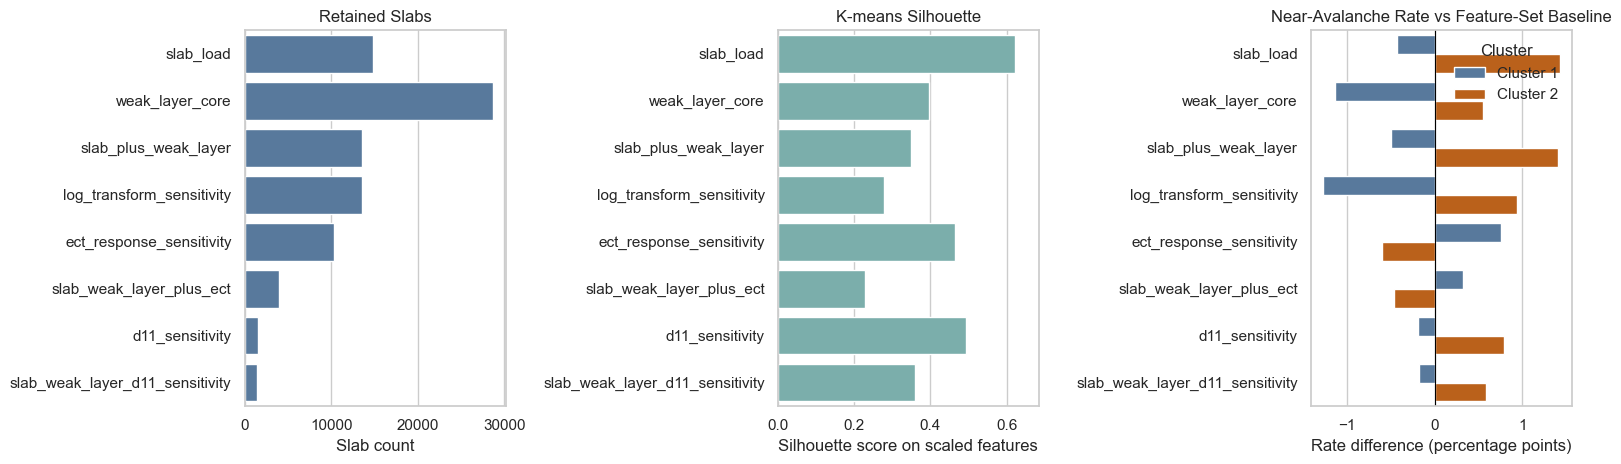

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.barplot(
    data=feature_set_summary_df,
    x="total_slabs_retained",
    y="feature_set",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Retained Slabs")
axes[0].set_xlabel("Slab count")
axes[0].set_ylabel("")

sns.barplot(
    data=feature_set_summary_df,
    x="kmeans_silhouette_score",
    y="feature_set",
    color="#72B7B2",
    ax=axes[1],
)
axes[1].set_title("K-means Silhouette")
axes[1].set_xlabel("Silhouette score on scaled features")
axes[1].set_ylabel("")
axes[1].set_xlim(0, max(0.05, feature_set_summary_df["kmeans_silhouette_score"].max() * 1.1))

sns.barplot(
    data=cluster_comparison_df,
    x="near_avalanche_rate_minus_baseline",
    y="feature_set",
    hue="cluster_label",
    palette={"Cluster 1": "#4C78A8", "Cluster 2": "#D55E00"},
    ax=axes[2],
)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Near-Avalanche Rate vs Feature-Set Baseline")
axes[2].set_xlabel("Rate difference (percentage points)")
axes[2].set_ylabel("")
axes[2].legend(title="Cluster", frameon=False)

fig.tight_layout()

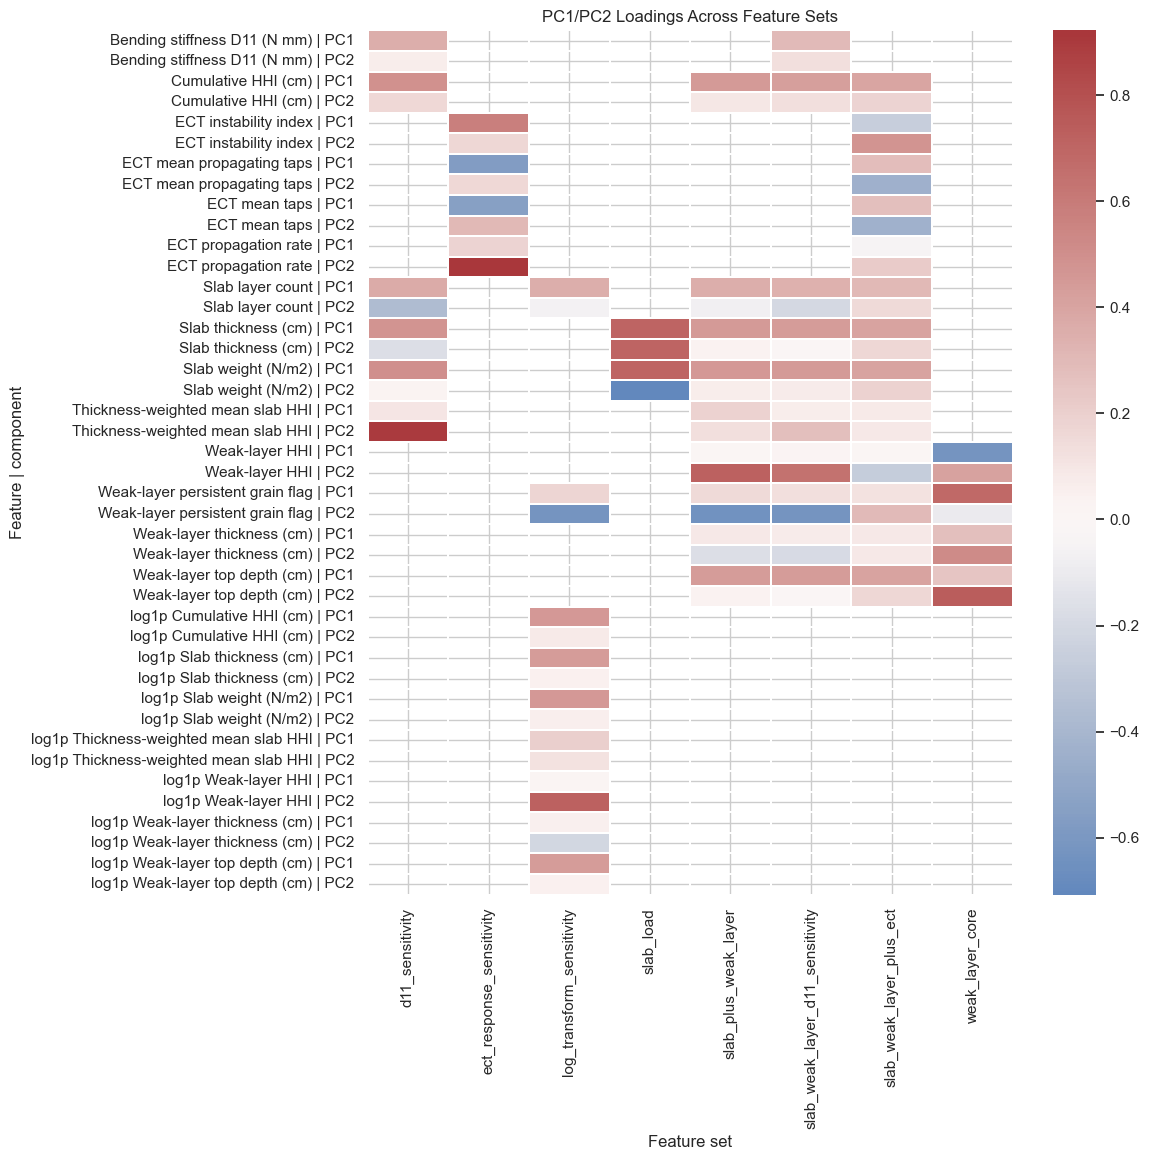

In [10]:
loading_heatmap_df = pca_loading_comparison_df.melt(
    id_vars=["feature_set", "display_name"],
    value_vars=["PC1", "PC2"],
    var_name="component",
    value_name="loading",
)
loading_heatmap_df["feature_component"] = (
    loading_heatmap_df["display_name"] + " | " + loading_heatmap_df["component"]
)
loading_pivot_df = loading_heatmap_df.pivot_table(
    index="feature_component",
    columns="feature_set",
    values="loading",
    aggfunc="first",
)

fig, axis = plt.subplots(figsize=(12, max(5, 0.28 * len(loading_pivot_df))))
sns.heatmap(
    loading_pivot_df,
    cmap="vlag",
    center=0,
    linewidths=0.2,
    linecolor="white",
    ax=axis,
)
axis.set_title("PC1/PC2 Loadings Across Feature Sets")
axis.set_xlabel("Feature set")
axis.set_ylabel("Feature | component")
fig.tight_layout()